In [1]:
import numpy as np
import pandas as pd
import missingno as msno
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
df1 = pd.read_csv("C:\\Users\\niraj\\OneDrive\\Desktop\\DecodeX\\CPASF.csv")
df2 = pd.read_csv("C:\\Users\\niraj\\OneDrive\\Desktop\\DecodeX\\CPMNT.csv")

In [5]:
df1.shape

(4228, 11)

In [7]:
df2.shape

(4168, 11)

In [9]:
df1.isnull().sum() * 100/len(df1)

Key             0.000000
Date            0.000000
Locations       0.000000
C&F Agent       0.000000
Division        0.000000
SKU             0.000000
Sales           0.000000
OpeningStock    0.000000
Receipts        0.000000
Forecast        0.000000
SellingPrice    8.751183
dtype: float64

In [11]:
df2.isnull().sum() * 100/len(df1)

Key              0.000000
Date             0.000000
Locations        0.000000
C&F Agent        0.000000
Division         0.000000
SKU              0.000000
Sales            0.000000
OpeningStock     0.000000
Receipts         0.000000
Forecast         0.000000
SellingPrice    40.137181
dtype: float64

In [13]:
df1['Date'] = pd.to_datetime(df1['Date'], format='%b-%y')
df1.head(20)

,Key,Date,Locations,C&F Agent,Division,SKU,Sales,OpeningStock,Receipts,Forecast,SellingPrice
0,37987AHMEDABAD AGENT 2PROD E,2004-01-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPASF,PROD E,4620,1530,3780,3494,NaN
1,38018AHMEDABAD AGENT 2PROD E,2004-02-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPASF,PROD E,3720,690,3600,3601,NaN
2,38047AHMEDABAD AGENT 2PROD E,2004-03-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPASF,PROD E,2550,570,7020,1888,NaN
3,38078AHMEDABAD AGENT 2PROD E,2004-04-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPASF,PROD E,10380,3600,11880,20592,9.00
4,38108AHMEDABAD AGENT 2PROD E,2004-05-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPASF,PROD E,5175,5100,3060,14668,9.00
5,38139AHMEDABAD AGENT 2PROD E,2004-06-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPASF,PROD E,7890,2985,6300,11894,9.00
6,38169AHMEDABAD AGENT 2PROD E,2004-07-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPASF,PROD E,3750,1395,6300,9576,9.00
7,38200AHMEDABAD AGENT 2PROD E,2004-08-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPASF,PROD E,3105,3945,4860,6888,9.00
8,38231AHMEDABAD AGENT 2PROD E,2004-09-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPASF,PROD E,4931,5700,7206,6123,9.00
9,38261AHMEDABAD AGENT 2PROD E,2004-10-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPASF,PROD E,3861,7975,1800,3921,10.26


In [244]:
df2['Date'] = pd.to_datetime(df1['Date'], format='%b-%y')
df2.head(20)

,Key,Date,Locations,C&F Agent,Division,SKU,Sales,OpeningStock,Receipts,Forecast,SellingPrice
0,37987AHMEDABAD AGENT 2PROD E,2004-01-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPMNT,PROD E,94560,90560,43680,83638,NaN
1,38018AHMEDABAD AGENT 2PROD E,2004-02-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPMNT,PROD E,71520,38720,77760,73595,NaN
2,38047AHMEDABAD AGENT 2PROD E,2004-03-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPMNT,PROD E,40320,44960,43200,73754,NaN
3,38078AHMEDABAD AGENT 2PROD E,2004-04-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPMNT,PROD E,86880,47840,60480,191354,6.15
4,38108AHMEDABAD AGENT 2PROD E,2004-05-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPMNT,PROD E,81600,20960,84960,163922,6.15
5,38139AHMEDABAD AGENT 2PROD E,2004-06-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPMNT,PROD E,117440,24320,125760,184000,6.15
6,38169AHMEDABAD AGENT 2PROD E,2004-07-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPMNT,PROD E,98400,32640,116640,210802,6.15
7,38200AHMEDABAD AGENT 2PROD E,2004-08-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPMNT,PROD E,84000,50400,89760,183118,6.20
8,38231AHMEDABAD AGENT 2PROD E,2004-09-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPMNT,PROD E,88320,56160,56640,100261,NaN
9,38261AHMEDABAD AGENT 2PROD E,2004-10-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPMNT,PROD E,89280,24480,92640,82248,NaN


In [15]:
df1['Year'] = df1['Date'].dt.year

In [17]:
nan1_count_per_year = df1.groupby(['Year','SKU'])['SellingPrice'].apply(lambda x: x.isna().sum())
nan1_count_per_year

Year  SKU   
2004  PROD A    63
      PROD B    65
      PROD C    68
      PROD D    67
      PROD E    67
2005  PROD A    15
      PROD B     6
      PROD C     0
      PROD D     2
      PROD E     0
2006  PROD A    11
      PROD B     4
      PROD C     1
      PROD D     0
      PROD E     1
Name: SellingPrice, dtype: int64

In [19]:
ttl1_count_per_year = df1.groupby(['Year','SKU'])['SellingPrice'].apply(lambda x: x.count())
ttl1_count_per_year

Year  SKU   
2004  PROD A    213
      PROD B    209
      PROD C    208
      PROD D    209
      PROD E    209
2005  PROD A    261
      PROD B    270
      PROD C    276
      PROD D    274
      PROD E    276
2006  PROD A    283
      PROD B    290
      PROD C    294
      PROD D    294
      PROD E    292
Name: SellingPrice, dtype: int64

In [23]:
df2['Year'] = df2['Date'].dt.year

AttributeError: Can only use .dt accessor with datetimelike values

In [25]:
nan2_count_per_year = df1.groupby(['Year','SKU'])['SellingPrice'].apply(lambda x: x.isna().sum())
nan2_count_per_year

Year  SKU   
2004  PROD A    63
      PROD B    65
      PROD C    68
      PROD D    67
      PROD E    67
2005  PROD A    15
      PROD B     6
      PROD C     0
      PROD D     2
      PROD E     0
2006  PROD A    11
      PROD B     4
      PROD C     1
      PROD D     0
      PROD E     1
Name: SellingPrice, dtype: int64

In [27]:
tt2_count_per_year = df2.groupby(['Year','SKU'])['SellingPrice'].apply(lambda x: x.count())
tt2_count_per_year

KeyError: 'Year'

In [29]:
df1.sort_values(by=["C&F Agent", "SKU","Date"],inplace = True)

In [300]:
df1

,Key,Date,Locations,C&F Agent,Division,SKU,Sales,OpeningStock,Receipts,Forecast,SellingPrice,Year
1727,37987AHMEDABAD AGENT 1PROD A,2004-01-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,20820,20820,0,13623,NaN,2004
1728,38018AHMEDABAD AGENT 1PROD A,2004-02-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,22590,0,30090,15428,NaN,2004
1729,38047AHMEDABAD AGENT 1PROD A,2004-03-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,9210,7140,20700,11546,NaN,2004
1730,38078AHMEDABAD AGENT 1PROD A,2004-04-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,9960,18630,27900,35696,14.87,2004
1731,38108AHMEDABAD AGENT 1PROD A,2004-05-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,25680,36570,2700,41912,14.87,2004
...,...,...,...,...,...,...,...,...,...,...,...,...
840,38930ZIRAKPUR AGENT 1PROD E,2006-08-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,5761,4554,1260,4624,10.43,2006
841,38961ZIRAKPUR AGENT 1PROD E,2006-09-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,7305,53,10440,9230,10.43,2006
842,38991ZIRAKPUR AGENT 1PROD E,2006-10-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,10028,2288,10080,7923,10.43,2006
843,39022ZIRAKPUR AGENT 1PROD E,2006-11-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,10230,1800,13500,3799,10.43,2006


In [31]:
df1.drop('Year',axis =1)

,Key,Date,Locations,C&F Agent,Division,SKU,Sales,OpeningStock,Receipts,Forecast,SellingPrice
1727,37987AHMEDABAD AGENT 1PROD A,2004-01-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,20820,20820,0,13623,NaN
1728,38018AHMEDABAD AGENT 1PROD A,2004-02-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,22590,0,30090,15428,NaN
1729,38047AHMEDABAD AGENT 1PROD A,2004-03-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,9210,7140,20700,11546,NaN
1730,38078AHMEDABAD AGENT 1PROD A,2004-04-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,9960,18630,27900,35696,14.87
1731,38108AHMEDABAD AGENT 1PROD A,2004-05-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,25680,36570,2700,41912,14.87
...,...,...,...,...,...,...,...,...,...,...,...
840,38930ZIRAKPUR AGENT 1PROD E,2006-08-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,5761,4554,1260,4624,10.43
841,38961ZIRAKPUR AGENT 1PROD E,2006-09-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,7305,53,10440,9230,10.43
842,38991ZIRAKPUR AGENT 1PROD E,2006-10-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,10028,2288,10080,7923,10.43
843,39022ZIRAKPUR AGENT 1PROD E,2006-11-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,10230,1800,13500,3799,10.43


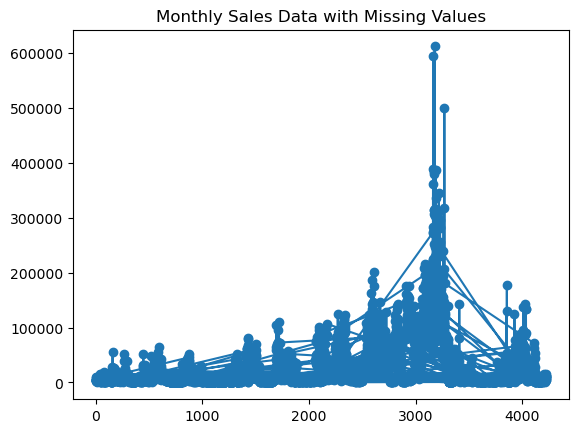

In [304]:
df1['Sales'].plot(title="Monthly Sales Data with Missing Values", marker='o')
plt.show()

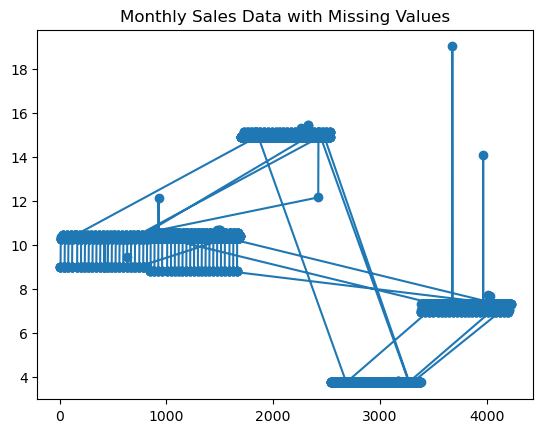

In [33]:
df1['SellingPrice'].plot(title="Monthly Sales Data with Missing Values", marker='o')
plt.show()

In [35]:
df1.set_index("Date", inplace=True)  # Set Date as index

# Apply backward fill
df1_bfilled = df1.bfill()
df1_bfilled

,Key,Locations,C&F Agent,Division,SKU,Sales,OpeningStock,Receipts,Forecast,SellingPrice,Year
Date,,,,,,,,,,,
2004-01-01,37987AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,20820,20820,0,13623,14.87,2004
2004-02-01,38018AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,22590,0,30090,15428,14.87,2004
2004-03-01,38047AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,9210,7140,20700,11546,14.87,2004
2004-04-01,38078AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,9960,18630,27900,35696,14.87,2004
2004-05-01,38108AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,25680,36570,2700,41912,14.87,2004
...,...,...,...,...,...,...,...,...,...,...,...
2006-08-01,38930ZIRAKPUR AGENT 1PROD E,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,5761,4554,1260,4624,10.43,2006
2006-09-01,38961ZIRAKPUR AGENT 1PROD E,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,7305,53,10440,9230,10.43,2006
2006-10-01,38991ZIRAKPUR AGENT 1PROD E,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,10028,2288,10080,7923,10.43,2006


In [269]:
df2.sort_values(by=["C&F Agent", "SKU","Date"],inplace = True)

In [271]:
df2

,Key,Date,Locations,C&F Agent,Division,SKU,Sales,OpeningStock,Receipts,Forecast,SellingPrice,Year
917,39022AHMEDABAD AGENT 1PROD A,2004-01-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPMNT,PROD A,2760000,936246,3075000,1983081,3.25,2004
918,39052AHMEDABAD AGENT 1PROD A,2004-02-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPMNT,PROD A,1567000,834164,2077000,2018718,3.25,2004
883,37987AHMEDABAD AGENT 1PROD A,2004-03-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPMNT,PROD A,227120,573,226880,169126,NaN,2004
884,38018AHMEDABAD AGENT 1PROD A,2004-04-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPMNT,PROD A,180800,333,180800,233389,NaN,2004
885,38047AHMEDABAD AGENT 1PROD A,2004-05-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPMNT,PROD A,131520,333,131520,112869,NaN,2004
...,...,...,...,...,...,...,...,...,...,...,...,...
840,38869ZIRAKPUR AGENT 1PROD E,2006-08-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPMNT,PROD E,76592,143792,1042560,70205,NaN,2006
841,38899ZIRAKPUR AGENT 1PROD E,2006-09-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPMNT,PROD E,90720,143040,765120,65099,6.20,2006
842,38930ZIRAKPUR AGENT 1PROD E,2006-10-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPMNT,PROD E,64800,27088,1112640,68970,NaN,2006
843,38961ZIRAKPUR AGENT 1PROD E,2006-11-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPMNT,PROD E,86880,239728,867840,117940,NaN,2006


In [273]:
df2_filled = df2.bfill().ffill()
df2_filled

,Key,Date,Locations,C&F Agent,Division,SKU,Sales,OpeningStock,Receipts,Forecast,SellingPrice,Year
917,39022AHMEDABAD AGENT 1PROD A,2004-01-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPMNT,PROD A,2760000,936246,3075000,1983081,3.25,2004
918,39052AHMEDABAD AGENT 1PROD A,2004-02-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPMNT,PROD A,1567000,834164,2077000,2018718,3.25,2004
883,37987AHMEDABAD AGENT 1PROD A,2004-03-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPMNT,PROD A,227120,573,226880,169126,3.25,2004
884,38018AHMEDABAD AGENT 1PROD A,2004-04-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPMNT,PROD A,180800,333,180800,233389,3.25,2004
885,38047AHMEDABAD AGENT 1PROD A,2004-05-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPMNT,PROD A,131520,333,131520,112869,3.25,2004
...,...,...,...,...,...,...,...,...,...,...,...,...
840,38869ZIRAKPUR AGENT 1PROD E,2006-08-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPMNT,PROD E,76592,143792,1042560,70205,6.20,2006
841,38899ZIRAKPUR AGENT 1PROD E,2006-09-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPMNT,PROD E,90720,143040,765120,65099,6.20,2006
842,38930ZIRAKPUR AGENT 1PROD E,2006-10-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPMNT,PROD E,64800,27088,1112640,68970,6.20,2006
843,38961ZIRAKPUR AGENT 1PROD E,2006-11-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPMNT,PROD E,86880,239728,867840,117940,6.20,2006


In [275]:
df2.set_index('Date', inplace=True)

In [277]:
df2_interpolated = df2.interpolate(method="time")
df2_interpolated

C:\Users\niraj\AppData\Local\Temp\ipykernel_40056\3081944404.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df2_interpolated = df2.interpolate(method="time")


,Key,Locations,C&F Agent,Division,SKU,Sales,OpeningStock,Receipts,Forecast,SellingPrice,Year
Date,,,,,,,,,,,
2004-01-01,39022AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPMNT,PROD A,2760000,936246,3075000,1983081,3.25,2004
2004-02-01,39052AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPMNT,PROD A,1567000,834164,2077000,2018718,3.25,2004
2004-03-01,37987AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPMNT,PROD A,227120,573,226880,169126,18.65,2004
2004-04-01,38018AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPMNT,PROD A,180800,333,180800,233389,7.47,2004
2004-05-01,38047AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPMNT,PROD A,131520,333,131520,112869,6.15,2004
...,...,...,...,...,...,...,...,...,...,...,...
2006-08-01,38869ZIRAKPUR AGENT 1PROD E,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPMNT,PROD E,76592,143792,1042560,70205,17.75,2006
2006-09-01,38899ZIRAKPUR AGENT 1PROD E,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPMNT,PROD E,90720,143040,765120,65099,6.20,2006
2006-10-01,38930ZIRAKPUR AGENT 1PROD E,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPMNT,PROD E,64800,27088,1112640,68970,5.34,2006


In [279]:
df2_interpolated.isnull().sum()

Key             0
Locations       0
C&F Agent       0
Division        0
SKU             0
Sales           0
OpeningStock    0
Receipts        0
Forecast        0
SellingPrice    0
Year            0
dtype: int64

#### If seasonality is strong, you might also use polynomial or spline interpolation

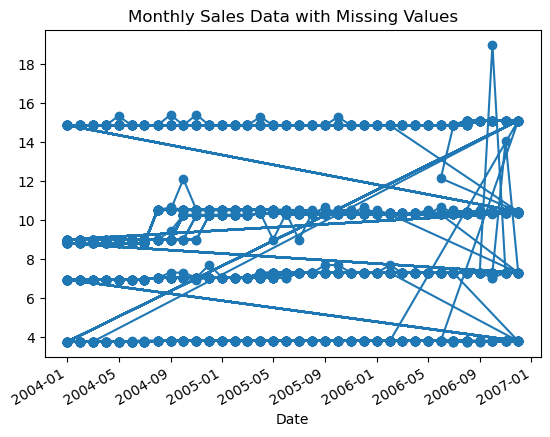

In [37]:
df1_bfilled['SellingPrice'].plot(title="Monthly Sales Data with Missing Values", marker='o')
plt.show()

- It looks like your backward fill (bfill) has created unnatural jumps in the data, leading to disconnected segments. This happens because bfill() fills missing values with the next available value, which may not maintain the seasonality of the time series.

In [41]:
df1_filled = df1.bfill().ffill()
df1_filled

,Key,Locations,C&F Agent,Division,SKU,Sales,OpeningStock,Receipts,Forecast,SellingPrice,Year
Date,,,,,,,,,,,
2004-01-01,37987AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,20820,20820,0,13623,14.87,2004
2004-02-01,38018AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,22590,0,30090,15428,14.87,2004
2004-03-01,38047AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,9210,7140,20700,11546,14.87,2004
2004-04-01,38078AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,9960,18630,27900,35696,14.87,2004
2004-05-01,38108AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,25680,36570,2700,41912,14.87,2004
...,...,...,...,...,...,...,...,...,...,...,...
2006-08-01,38930ZIRAKPUR AGENT 1PROD E,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,5761,4554,1260,4624,10.43,2006
2006-09-01,38961ZIRAKPUR AGENT 1PROD E,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,7305,53,10440,9230,10.43,2006
2006-10-01,38991ZIRAKPUR AGENT 1PROD E,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,10028,2288,10080,7923,10.43,2006


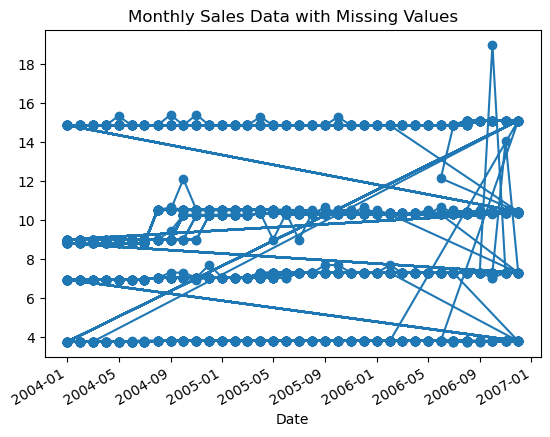

In [43]:
df1_filled['SellingPrice'].plot(title="Monthly Sales Data with Missing Values", marker='o')
plt.show()

In [45]:
df1_interpolated = df1.interpolate(method="time")
df1_interpolated

C:\Users\niraj\AppData\Local\Temp\ipykernel_2724\4038288945.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df1_interpolated = df1.interpolate(method="time")


,Key,Locations,C&F Agent,Division,SKU,Sales,OpeningStock,Receipts,Forecast,SellingPrice,Year
Date,,,,,,,,,,,
2004-01-01,37987AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,20820,20820,0,13623,NaN,2004
2004-02-01,38018AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,22590,0,30090,15428,NaN,2004
2004-03-01,38047AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,9210,7140,20700,11546,NaN,2004
2004-04-01,38078AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,9960,18630,27900,35696,14.87,2004
2004-05-01,38108AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,25680,36570,2700,41912,14.87,2004
...,...,...,...,...,...,...,...,...,...,...,...
2006-08-01,38930ZIRAKPUR AGENT 1PROD E,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,5761,4554,1260,4624,10.43,2006
2006-09-01,38961ZIRAKPUR AGENT 1PROD E,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,7305,53,10440,9230,10.43,2006
2006-10-01,38991ZIRAKPUR AGENT 1PROD E,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,10028,2288,10080,7923,10.43,2006


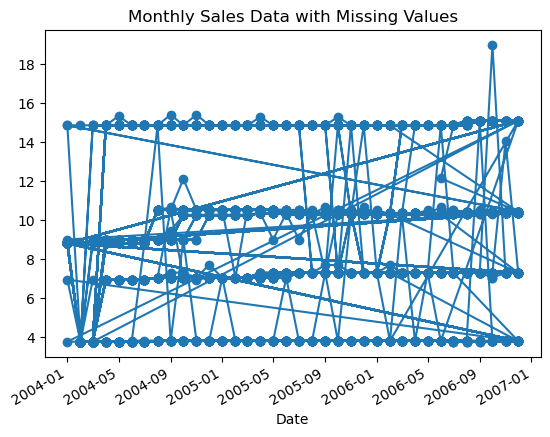

In [47]:
df1_interpolated['SellingPrice'].plot(title="Monthly Sales Data with Missing Values", marker='o')
plt.show()

In [49]:
df_filled1 = df1.copy()  # Copy original data

In [51]:
df_filled1['SellingPrice'] = df_filled1['SellingPrice'].fillna(df_filled1['SellingPrice'].rolling(window=3, min_periods=1).mean())
df_filled1

,Key,Locations,C&F Agent,Division,SKU,Sales,OpeningStock,Receipts,Forecast,SellingPrice,Year
Date,,,,,,,,,,,
2004-01-01,37987AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,20820,20820,0,13623,NaN,2004
2004-02-01,38018AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,22590,0,30090,15428,NaN,2004
2004-03-01,38047AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,9210,7140,20700,11546,NaN,2004
2004-04-01,38078AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,9960,18630,27900,35696,14.87,2004
2004-05-01,38108AHMEDABAD AGENT 1PROD A,AHMEDABAD BRANCH,AHMEDABAD AGENT 1,CPASF,PROD A,25680,36570,2700,41912,14.87,2004
...,...,...,...,...,...,...,...,...,...,...,...
2006-08-01,38930ZIRAKPUR AGENT 1PROD E,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,5761,4554,1260,4624,10.43,2006
2006-09-01,38961ZIRAKPUR AGENT 1PROD E,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,7305,53,10440,9230,10.43,2006
2006-10-01,38991ZIRAKPUR AGENT 1PROD E,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPASF,PROD E,10028,2288,10080,7923,10.43,2006


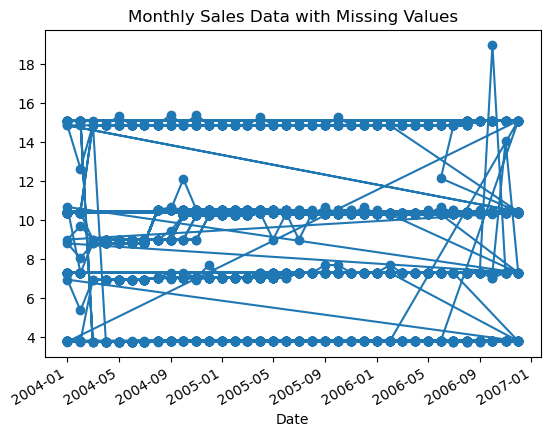

In [53]:
df_filled1['SellingPrice'].plot(title="Monthly Sales Data with Missing Values", marker='o')
plt.show()

In [209]:
from statsmodels.tsa.seasonal import seasonal_decompose

- model='additive': Use when trend and seasonality remain constant over time.
- model='multiplicative': Use when seasonality grows/shrinks proportionally with the data.

- If selling prices are relatively stable over time, with seasonal fluctuations staying constant, an additive model is better.
- If selling prices increase or decrease significantly over time, and the seasonal effect scales with price levels, a multiplicative model is better.

In [211]:
df_filled2 = df1.copy()

In [212]:
decomposition = seasonal_decompose(df1_filled['SellingPrice'], model='additive', period=12)  # Adjust period based on data

In [213]:
# Fill missing values separately for each component
trend_filled = decomposition.trend.interpolate()
seasonal_filled = decomposition.seasonal  # Seasonality remains unchanged
residual_filled = decomposition.resid.interpolate()

# Reconstruct the series
df_filled1_1 = trend_filled + seasonal_filled + residual_filled

In [214]:
df_filled1_1['SellingPrice'].plot(title="Monthly Sales Data with Missing Values", marker='o')
plt.show()

KeyError: 'SellingPrice'

#### Advanced: Machine Learning Imputation
#### For very complex missing patterns, you can train a machine learning model (like Random Forest Regressor or LSTMs) to predict missing values based on past trends.

In [ ]:
#seasonality check for 2nd data

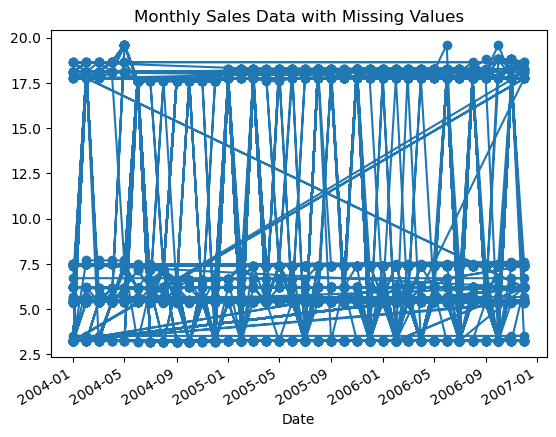

In [216]:

df2_interpolated['SellingPrice'].plot(title="Monthly Sales Data with Missing Values", marker='o')
plt.show()